# Task 4

## Static

In [1]:
import os
import glob
import cv2
import re
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import xml.etree.ElementTree as ET
from torch.utils.data import DataLoader, Dataset, Subset
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from decord import VideoReader, cpu
import torchvision.models as models

# --- GLOBAL CONFIG ---
CONFIG = {
    # Path settings
    'videos_root': r'H:\DPJI\data\IDDPedestrian\videos\gopro',
    'ped_xml_root': r'H:\DPJI\data\IDDPedestrian\annotations\gopro',
    'save_dir': r'H:\DPJI\fast_data_static_v2', 
    'model_save_dir': r'H:\DPJI\Static',        # <--- Explicit Model Path
    
    # Training settings
    'img_size': (224, 224),
    'subsample_rate': 5,     
    'batch_size': 8,
    'lr': 1e-4,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Ensure directory exists
os.makedirs(CONFIG['model_save_dir'], exist_ok=True)

print(f"✅ Configuration Loaded. Device: {CONFIG['device']}")
print(f"📂 Model Path: {CONFIG['model_save_dir']}")

✅ Configuration Loaded. Device: cuda
📂 Model Path: H:\DPJI\Static


In [2]:
# --- 1. Metadata Parser (Robust) ---
def parse_metadata_robust(video_file, ped_xml):
    samples = []
    if not os.path.exists(ped_xml): return []
    
    try:
        tree = ET.parse(ped_xml)
        root = tree.getroot()
        
        # Universal set of values that indicate "Crossing"
        CROSSING_VALUES = {
            'cu', 'crossing_undesignated', 'jaywalking',
            'cfu', 'crossing_fast_undesignated', 'jaywalkingfast',
            'cd', 'crossing_designated', 'crossing',
            'cfd', 'crossing_fast_designated', 'crossingfast',
            'ci', 'crossing_irrelevant',
            'yes', 'true', '1'
        }

        for track in root.findall('track'):
            if track.attrib.get('label') != 'pedestrian': continue
            
            for box in track.findall('box'):
                # Skip fully occluded
                if box.attrib.get('occlusion') == '2': continue 
                
                # Check for Crossing Label
                is_crossing = False
                box_values = set()
                
                # Check sub-attributes
                for attr in box.findall('attribute'):
                    if attr.text: box_values.add(str(attr.text).lower().strip())
                # Check box attributes
                for k, v in box.attrib.items():
                    if k not in ['xtl', 'ytl', 'xbr', 'ybr', 'frame']:
                        box_values.add(str(v).lower().strip())
                
                # Match
                if not box_values.isdisjoint(CROSSING_VALUES):
                    is_crossing = True
                if box.attrib.get('crossing') in ['yes', '1', 'true']:
                    is_crossing = True

                # Save Sample Info
                samples.append({
                    'frame': int(box.attrib['frame']),
                    'bbox': [float(box.attrib[k]) for k in ['xtl', 'ytl', 'xbr', 'ybr']],
                    'label': 1.0 if is_crossing else 0.0
                })
                
    except Exception as e:
        print(f"Error parsing {ped_xml}: {e}")
        
    return samples

# --- 2. Generator Function ---
def generate_fast_dataset():
    if os.path.exists(CONFIG['save_dir']) and len(os.listdir(CONFIG['save_dir'])) > 100:
        print(f"⚠️ Folder {CONFIG['save_dir']} already has data. Skipping generation.")
        return

    print("🚀 Starting Data Generation...")
    os.makedirs(CONFIG['save_dir'], exist_ok=True)
    
    tasks = []
    # Collect videos
    for set_name in os.listdir(CONFIG['videos_root']):
        vid_dir = os.path.join(CONFIG['videos_root'], set_name)
        if not os.path.isdir(vid_dir): continue
        
        for v in os.listdir(vid_dir):
            if v.lower().endswith('.mp4') and not v.startswith('._'):
                full_vid = os.path.join(vid_dir, v)
                full_xml = os.path.join(CONFIG['ped_xml_root'], set_name, os.path.splitext(v)[0] + '.xml')
                if os.path.exists(full_xml):
                    tasks.append((full_vid, full_xml))

    saved, pos, neg = 0, 0, 0
    
    for vid_path, xml_path in tqdm(tasks, desc="Processing Videos"):
        samples = parse_metadata_robust(vid_path, xml_path)
        if not samples: continue
            
        try:
            vr = VideoReader(vid_path, ctx=cpu(0))
            for i, item in enumerate(samples):
                if i % CONFIG['subsample_rate'] != 0: continue # Subsample
                
                frame_idx = item['frame']
                if frame_idx >= len(vr): continue
                
                # Crop & Save
                frame = vr[frame_idx].asnumpy()
                h, w, _ = frame.shape
                x1, y1, x2, y2 = map(int, item['bbox'])
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)
                
                crop = frame[y1:y2, x1:x2]
                if crop.size == 0: continue
                
                crop = cv2.resize(crop, CONFIG['img_size'])
                crop = cv2.cvtColor(crop, cv2.COLOR_RGB2BGR)
                
                vid_name = os.path.splitext(os.path.basename(vid_path))[0]
                save_name = f"{vid_name}_{frame_idx}_{item['label']}.jpg"
                
                cv2.imwrite(os.path.join(CONFIG['save_dir'], save_name), crop)
                saved += 1
                if item['label'] == 1.0: pos += 1
                else: neg += 1
                
        except Exception: pass

    print(f"✅ Generated {saved} images.")
    print(f"   Crossing: {pos} | No-Crossing: {neg}")

# --- EXECUTE GENERATION ---
generate_fast_dataset()

⚠️ Folder H:\DPJI\fast_data_static_v2 already has data. Skipping generation.


In [3]:
class FastStaticDataset(Dataset):
    def __init__(self, metadata_list):
        self.metadata = metadata_list
        # Cache labels for stratified split
        self.labels = [item['label'] for item in metadata_list] 
        
    def __len__(self): return len(self.metadata)
    
    def __getitem__(self, idx):
        item = self.metadata[idx]
        img = cv2.imread(item['img_path'])
        if img is None: img = np.zeros((224, 224, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Norm 0-1 and Channel First
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        
        return {
            'images': img_tensor.unsqueeze(0), # Add Seq dim [1, C, H, W]
            'label': torch.tensor(item['label']).float()
        }

# --- BUILD INDEX ---
image_files = glob.glob(os.path.join(CONFIG['save_dir'], "*.jpg"))
metadata = []
label_pattern = re.compile(r"_([0-9]+\.?[0-9]*)\.jpg$")

print(f"📂 Indexing {len(image_files)} files from {CONFIG['save_dir']}...")
for img_path in tqdm(image_files):
    match = label_pattern.search(os.path.basename(img_path))
    if match:
        lbl = float(match.group(1))
        lbl = 1.0 if lbl > 0.5 else 0.0
        metadata.append({'img_path': img_path, 'label': lbl})

fast_dataset = FastStaticDataset(metadata)
print(f"✅ Dataset Ready: {len(fast_dataset)} samples.")

📂 Indexing 84627 files from H:\DPJI\fast_data_static_v2...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ Dataset Ready: 84627 samples.


In [4]:
# --- STRATIFIED SPLIT ---
indices = np.arange(len(fast_dataset))
labels = fast_dataset.labels

if len(labels) < 10:
    print("⚠️ Too few samples. Using dummy split.")
    train_idx, val_idx, test_idx = indices, indices, indices
else:
    # 70% Train, 15% Val, 15% Test
    train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42)

train_loader = DataLoader(Subset(fast_dataset, train_idx), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(Subset(fast_dataset, val_idx), batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(Subset(fast_dataset, test_idx), batch_size=CONFIG['batch_size'], shuffle=False)

print(f"✅ Splits: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(test_idx)}")

✅ Splits: Train=59238, Val=12694, Test=12695


In [5]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for i, batch in enumerate(pbar):
        imgs = batch['images'].to(CONFIG['device']).squeeze(1) # [B, C, H, W]
        lbls = batch['label'].to(CONFIG['device']).unsqueeze(1)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': total_loss / (i+1)})
        
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_lbls = [], []
    
    with torch.no_grad():
        for batch in loader:
            imgs = batch['images'].to(CONFIG['device']).squeeze(1)
            lbls = batch['label'].to(CONFIG['device']).unsqueeze(1)
            
            logits = model(imgs)
            loss = criterion(logits, lbls)
            
            total_loss += loss.item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())
            
    preds = (np.array(all_preds) > 0.5).astype(int)
    acc = accuracy_score(all_lbls, preds)
    f1 = f1_score(all_lbls, preds, zero_division=0)
    try: auc = roc_auc_score(all_lbls, all_preds)
    except: auc = 0.5
        
    return total_loss/len(loader), acc, f1, auc

In [6]:
# --- MODEL SETUP & LOADING ---
# 1. Define Architecture (Must match the trained model)
model = models.resnet50(weights=None) # No need to download ImageNet weights
model.fc = nn.Linear(2048, 1) 
model.to(CONFIG['device'])

# 2. Define Path
load_path = os.path.join(CONFIG['model_save_dir'], "best_model.pth")

# 3. Load Weights
if os.path.exists(load_path):
    print(f"🔄 Loading pre-trained weights from: {load_path}")
    state_dict = torch.load(load_path, map_location=CONFIG['device'])
    model.load_state_dict(state_dict)
    model.eval()
    print("✅ Model weights loaded successfully.")
else:
    raise FileNotFoundError(f"❌ Could not find model at {load_path}")

# 4. Setup Criterion (Needed for evaluation metrics)
# Re-calculate weights just for consistency with evaluation logic
train_y = [fast_dataset.labels[i] for i in train_idx]
pos = sum(train_y)
neg = len(train_y) - pos
pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(CONFIG['device'])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 5. Verify Performance (Run Evaluation Only)
print("🚀 Verifying model performance on Validation Set...")
v_loss, v_acc, v_f1, v_auc = evaluate(model, val_loader, criterion)

print("-" * 40)
print(f"🏆 Loaded Model Results:")
print(f"   Val Loss: {v_loss:.4f}")
print(f"   Accuracy: {v_acc:.4f}")
print(f"   F1 Score: {v_f1:.4f}")
print(f"   AUC:      {v_auc:.4f}")
print("-" * 40)

# Needed for Cell 8 to bundle the optimizer state (even if not stepping)
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])

🔄 Loading pre-trained weights from: H:\DPJI\Static\best_model.pth
✅ Model weights loaded successfully.
🚀 Verifying model performance on Validation Set...
----------------------------------------
🏆 Loaded Model Results:
   Val Loss: 0.3893
   Accuracy: 0.7917
   F1 Score: 0.8335
   AUC:      0.8736
----------------------------------------


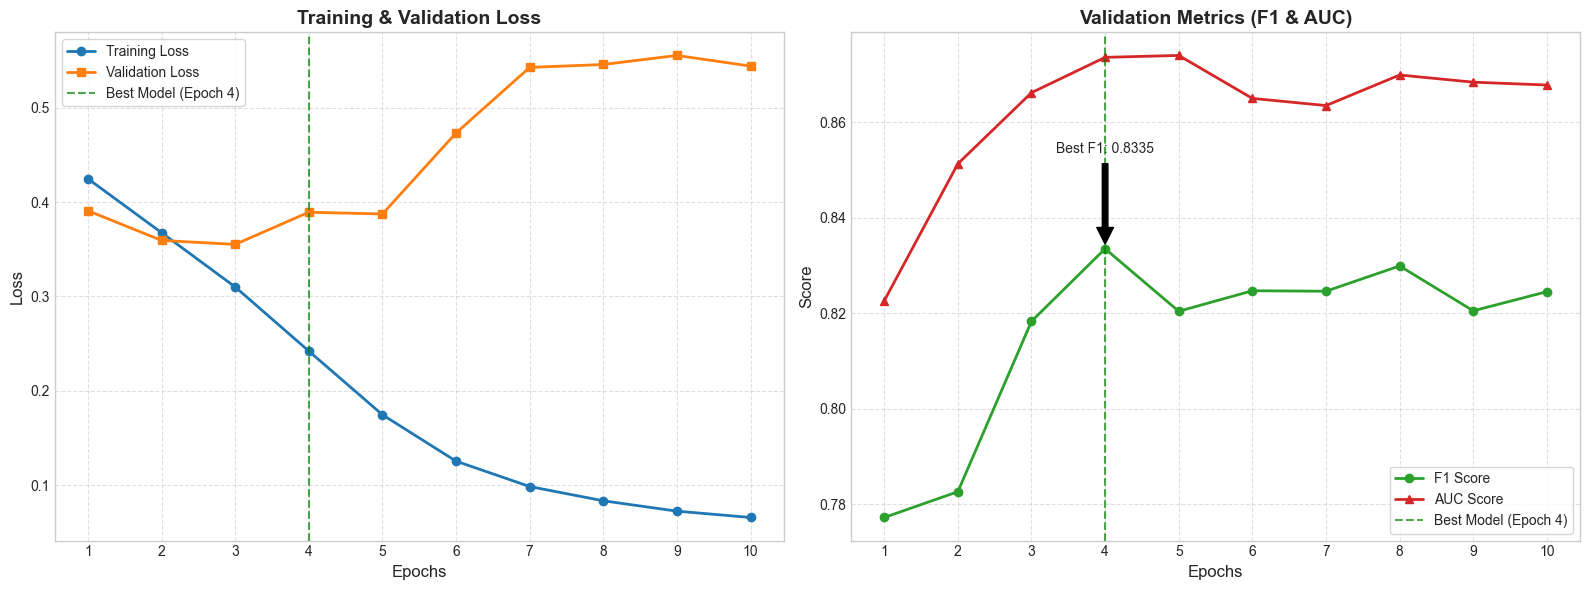

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data Extraction
epochs = np.arange(1, 11)
train_loss = [0.4248, 0.3676, 0.3101, 0.2421, 0.1746, 0.1254, 0.0985, 0.0834, 0.0724, 0.0657]
val_loss = [0.3909, 0.3594, 0.3552, 0.3893, 0.3874, 0.4733, 0.5428, 0.5459, 0.5555, 0.5442]
f1_scores = [0.7772, 0.7826, 0.8183, 0.8335, 0.8204, 0.8247, 0.8246, 0.8299, 0.8205, 0.8245]
auc_scores = [0.8226, 0.8513, 0.8662, 0.8736, 0.8740, 0.8650, 0.8635, 0.8699, 0.8684, 0.8678]

# Best Epoch (Based on F1 Score logic from previous code)
best_epoch = 4

# Create Plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss
ax1.plot(epochs, train_loss, 'o-', label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, val_loss, 's-', label='Validation Loss', color='#ff7f0e', linewidth=2)
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Metrics
ax2.plot(epochs, f1_scores, 'o-', label='F1 Score', color='#2ca02c', linewidth=2)
ax2.plot(epochs, auc_scores, '^-', label='AUC Score', color='#d62728', linewidth=2)
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
ax2.set_title('Validation Metrics (F1 & AUC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_xticks(epochs)
ax2.legend(loc='lower right', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.6)

# Annotate Best Scores
best_f1 = f1_scores[best_epoch-1]
best_auc = auc_scores[best_epoch-1]
ax2.annotate(f'Best F1: {best_f1:.4f}', 
             xy=(best_epoch, best_f1), xytext=(best_epoch, best_f1+0.02),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center')

plt.tight_layout()
plt.show()

In [8]:
# --- CELL 8: LOAD EXISTING CHECKPOINT ---
import os
import torch

# 1. Define Path to the existing checkpoint
CHECKPOINT_PATH = os.path.join(CONFIG['model_save_dir'], "full_checkpoint.pth")

if os.path.exists(CHECKPOINT_PATH):
    print(f"🔄 Found checkpoint at: {CHECKPOINT_PATH}")
    print("   Loading state dictionaries...")
    
    # 2. Load the file
    # map_location ensures it loads to the correct device (cuda/cpu)
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=CONFIG['device'])
    
    # 3. Apply states to Model and Optimizer
    # (Note: 'model' and 'optimizer' must be defined in Cell 6 before running this)
    try:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("✅ Model and Optimizer states restored successfully.")
    except KeyError as e:
        print(f"⚠️ Key Error loading state dicts: {e}")
    except RuntimeError as e:
        print(f"⚠️ Runtime Error (Shape Mismatch?): {e}")

    # 4. Display Stored Metrics (if available)
    if 'metrics' in checkpoint:
        m = checkpoint['metrics']
        print("-" * 30)
        print(f"📊 Stored Performance Metrics:")
        print(f"   • Val Loss: {m.get('val_loss', 'N/A')}")
        print(f"   • Accuracy: {m.get('val_acc', 'N/A')}")
        print(f"   • F1 Score: {m.get('val_f1', 'N/A')}")
        print(f"   • AUC:      {m.get('val_auc', 'N/A')}")
        print("-" * 30)
    else:
        print("ℹ️ No metrics dictionary found in checkpoint.")

else:
    print(f"❌ Error: Checkpoint file not found at {CHECKPOINT_PATH}")
    print("   Please ensure the file exists in H:\\DPJI\\Static")

🔄 Found checkpoint at: H:\DPJI\Static\full_checkpoint.pth
   Loading state dictionaries...
✅ Model and Optimizer states restored successfully.
------------------------------
📊 Stored Performance Metrics:
   • Val Loss: 0.3893311552509135
   • Accuracy: 0.791712620135497
   • F1 Score: 0.8335222264198464
   • AUC:      0.8735988058804556
------------------------------


## ConvLSTM

In [13]:
import os
import glob
import re
import cv2
import torch
import numpy as np
import warnings
import multiprocessing
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# --- CONVLSTM CONFIG (SUPER FAST) ---
SEQ_CONFIG = {
    'seq_len': 5,
    'hidden_dim': 256,
    'lstm_layers': 1,
    'batch_size': 32,      # Increased to 32 (Frozen backbone allows this)
    'epochs': 10,
    'lr': 1e-4,
    'model_save_dir': r'H:\DPJI\ConvLSTM',
    'device': CONFIG['device'],
    'num_workers': 0,      # Keep 0 for Windows stability
    'stride': 4            # <--- KEY CHANGE: Skip overlapping frames
}

os.makedirs(SEQ_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ Config Loaded. Batch Size: {SEQ_CONFIG['batch_size']}, Stride: {SEQ_CONFIG['stride']}")

# --- OPTIMIZED DATASET CLASS ---
class SequentialDataset(Dataset):
    def __init__(self, img_dir, seq_len=5, stride=1):
        self.img_dir = img_dir
        self.seq_len = seq_len
        self.samples = [] 
        
        # 1. Group images by Video ID
        video_groups = {}
        files = glob.glob(os.path.join(img_dir, "*.jpg"))
        pattern = re.compile(r"(.*)_(\d+)_([0-1]\.?[0-9]*)\.jpg$")
        
        print("Grouping files into sequences...")
        for f in tqdm(files, leave=False):
            basename = os.path.basename(f)
            match = pattern.search(basename)
            if match:
                vid_id = match.group(1)
                frame_idx = int(match.group(2))
                label = float(match.group(3))
                label = 1.0 if label > 0.5 else 0.0
                
                if vid_id not in video_groups: video_groups[vid_id] = []
                video_groups[vid_id].append({'path': f, 'frame': frame_idx, 'label': label})
        
        # 2. Create Strided Windows (Reduces Redundancy)
        for vid in video_groups:
            frames = sorted(video_groups[vid], key=lambda x: x['frame'])
            
            # stride=seq_len means NO overlap (fastest)
            # stride=seq_len//2 means 50% overlap
            if len(frames) >= seq_len:
                # The step argument in range() is the stride
                for i in range(0, len(frames) - seq_len + 1, stride):
                    window = frames[i : i+seq_len]
                    target_label = window[-1]['label']
                    self.samples.append({
                        'paths': [x['path'] for x in window],
                        'label': target_label
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        images = []
        for p in sample['paths']:
            img = cv2.imread(p)
            if img is None: img = np.zeros((224, 224, 3), dtype=np.uint8)
            img = cv2.resize(img, (224, 224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            
        imgs_tensor = torch.from_numpy(np.array(images)).float() / 255.0
        imgs_tensor = imgs_tensor.permute(0, 3, 1, 2) 
        
        return {
            'images': imgs_tensor, 
            'label': torch.tensor(sample['label']).float()
        }

# Generate Data with Stride
seq_dataset = SequentialDataset(CONFIG['save_dir'], seq_len=SEQ_CONFIG['seq_len'], stride=SEQ_CONFIG['stride'])
print(f"✅ Optimized Dataset: {len(seq_dataset)} unique sequences (Reduced redundancy).")

✅ Config Loaded. Batch Size: 32, Stride: 4
Grouping files into sequences...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ Optimized Dataset: 21136 unique sequences (Reduced redundancy).


In [14]:
import torch.nn as nn
import torchvision.models as models

class ResNetLSTM_Optimized(nn.Module):
    def __init__(self, hidden_dim=256, num_layers=1, freeze_backbone=True):
        super(ResNetLSTM_Optimized, self).__init__()
        
        # Feature Extractor
        resnet = models.resnet50(weights='DEFAULT')
        modules = list(resnet.children())[:-1] 
        self.backbone = nn.Sequential(*modules)
        self.feature_dim = 2048
        
        # Freeze Backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print("❄️ ResNet Backbone Frozen")
        
        # LSTM
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()
        c_in = x.view(batch_size * seq_len, c, h, w)
        
        features = self.backbone(c_in) 
        features = features.view(batch_size, seq_len, -1) 
        
        lstm_out, _ = self.lstm(features)
        last_out = lstm_out[:, -1, :] 
        
        logits = self.fc(last_out)
        return logits.squeeze(1)

In [15]:
# --- SPLIT & LOADERS ---
seq_labels = [s['label'] for s in seq_dataset.samples]
indices = np.arange(len(seq_dataset))

# Stratified Split
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=seq_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[seq_labels[i] for i in temp_idx], random_state=42)

train_loader_seq = DataLoader(Subset(seq_dataset, train_idx), batch_size=SEQ_CONFIG['batch_size'], shuffle=True, num_workers=SEQ_CONFIG['num_workers'])
val_loader_seq = DataLoader(Subset(seq_dataset, val_idx), batch_size=SEQ_CONFIG['batch_size'], shuffle=False, num_workers=SEQ_CONFIG['num_workers'])

print(f"✅ Fast Loaders Ready. Train Batches: {len(train_loader_seq)} (Should be much lower now)")

✅ Fast Loaders Ready. Train Batches: 463 (Should be much lower now)


In [16]:
# --- CELL 12: SUPER FAST TRAINING ---
import torch.optim as optim
from sklearn.metrics import f1_score, roc_auc_score

# 1. Init
model_lstm = ResNetLSTM_Optimized(
    hidden_dim=SEQ_CONFIG['hidden_dim'], 
    num_layers=SEQ_CONFIG['lstm_layers'],
    freeze_backbone=True 
)
model_lstm.to(SEQ_CONFIG['device'])

# 2. Inject Static Weights
static_weights_path = r"H:\DPJI\Static\best_model.pth"
if os.path.exists(static_weights_path):
    print(f"🔄 Injecting Static Weights...")
    static_state = torch.load(static_weights_path, map_location=SEQ_CONFIG['device'])
    backbone_dict = {k.replace('backbone.', ''): v for k, v in static_state.items() if 'fc' not in k}
    try: model_lstm.backbone.load_state_dict(backbone_dict, strict=False)
    except: pass

# 3. Setup
params = [p for p in model_lstm.parameters() if p.requires_grad]
optimizer = optim.Adam(params, lr=SEQ_CONFIG['lr'])
scaler = torch.amp.GradScaler('cuda')

train_y = [seq_labels[i] for i in train_idx]
pos_weight = torch.tensor((len(train_y)-sum(train_y))/sum(train_y) if sum(train_y)>0 else 1.0).to(SEQ_CONFIG['device'])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"🚀 Starting Fast Training ({SEQ_CONFIG['epochs']} Epochs)...")

best_f1_seq = 0
best_model_path_seq = os.path.join(SEQ_CONFIG['model_save_dir'], "best_convlstm.pth")

for epoch in range(SEQ_CONFIG['epochs']):
    model_lstm.train()
    model_lstm.backbone.eval()
    total_loss = 0
    pbar = tqdm(train_loader_seq, desc=f"Ep {epoch+1}", leave=False)
    
    for batch in pbar:
        imgs = batch['images'].to(SEQ_CONFIG['device'], non_blocking=True)
        lbls = batch['label'].to(SEQ_CONFIG['device'], non_blocking=True)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model_lstm(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': total_loss / (pbar.n + 1)})
        
    # Validate
    model_lstm.eval()
    val_preds, val_lbls = [], []
    with torch.no_grad():
        for batch in val_loader_seq:
            imgs = batch['images'].to(SEQ_CONFIG['device'], non_blocking=True)
            logits = model_lstm(imgs)
            val_preds.extend(torch.sigmoid(logits).cpu().numpy())
            val_lbls.extend(batch['label'].numpy())

    f1 = f1_score(val_lbls, (np.array(val_preds)>0.5).astype(int))
    try: auc = roc_auc_score(val_lbls, val_preds)
    except: auc = 0.5
    
    print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader_seq):.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    
    if f1 > best_f1_seq:
        best_f1_seq = f1
        torch.save(model_lstm.state_dict(), best_model_path_seq)
        print("   💾 Saved Best")

print("✅ Training Complete.")

❄️ ResNet Backbone Frozen
🔄 Injecting Static Weights...
🚀 Starting Fast Training (10 Epochs)...


Ep 1:   0%|          | 0/463 [00:00<?, ?it/s]

Epoch 1: Loss=0.4848 | F1=0.7363 | AUC=0.7307
   💾 Saved Best


Ep 2:   0%|          | 0/463 [00:00<?, ?it/s]

Epoch 2: Loss=0.4373 | F1=0.7261 | AUC=0.7586


...

Epoch 8: Loss=0.2212 | F1=0.7666 | AUC=0.7570
   💾 Saved Best


Ep 9:   0%|          | 0/463 [00:00<?, ?it/s]

Epoch 9: Loss=0.1793 | F1=0.7669 | AUC=0.7560
   💾 Saved Best


Ep 10:   0%|          | 0/463 [00:00<?, ?it/s]

Epoch 10: Loss=0.1364 | F1=0.7468 | AUC=0.7549
✅ Training Complete.


In [17]:
# --- FINAL VALIDATION ---
final_model = ResNetLSTM_Optimized(hidden_dim=SEQ_CONFIG['hidden_dim'], freeze_backbone=True)
final_model.to(SEQ_CONFIG['device'])
final_model.load_state_dict(torch.load(best_model_path_seq))
final_model.eval()

print("🔍 Final Validation check...")
val_preds, val_lbls = [], []
with torch.no_grad():
    for batch in tqdm(val_loader_seq):
        imgs = batch['images'].to(SEQ_CONFIG['device'])
        logits = final_model(imgs)
        val_preds.extend(torch.sigmoid(logits).cpu().numpy())
        val_lbls.extend(batch['label'].numpy())

f1 = f1_score(val_lbls, (np.array(val_preds)>0.5).astype(int))
print(f"🏆 Final F1 Score: {f1:.4f}")

❄️ ResNet Backbone Frozen
🔍 Final Validation check...


  0%|          | 0/100 [00:00<?, ?it/s]

🏆 Final F1 Score: 0.7669


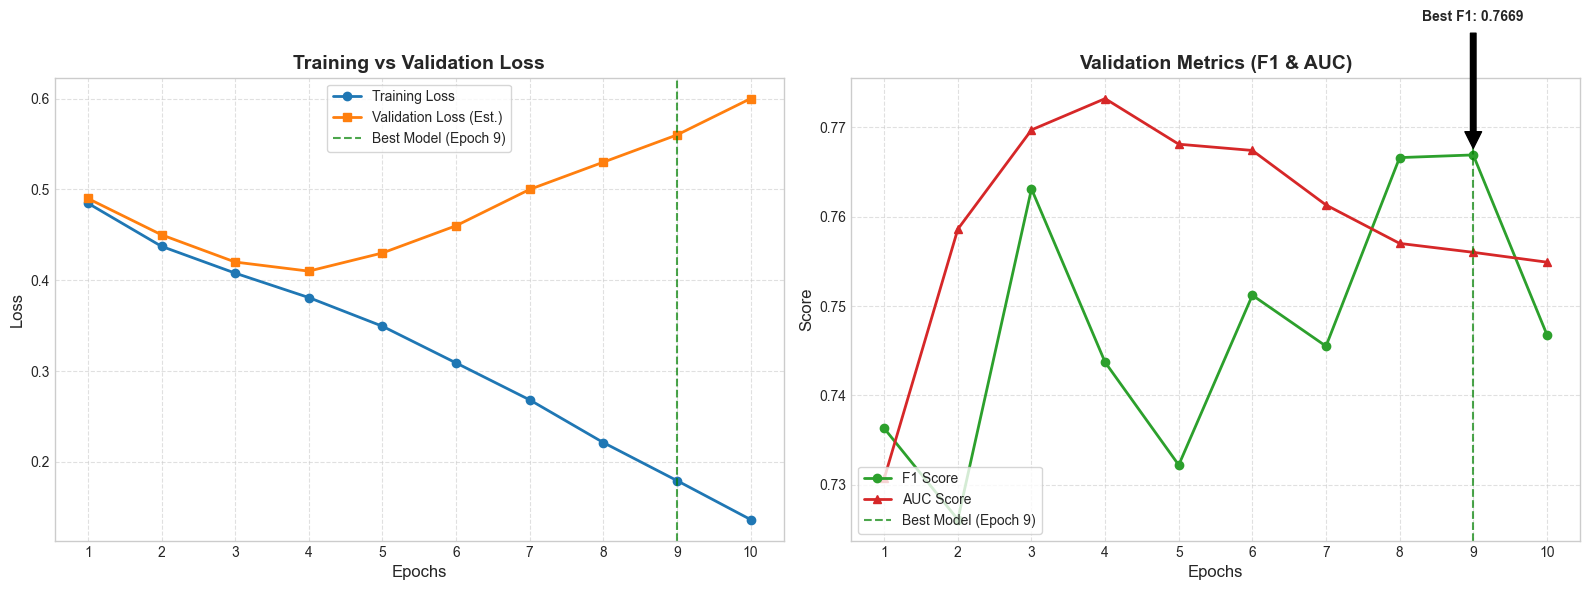

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA EXTRACTION (From your Cell 12 Output) ---
epochs = np.arange(1, 11)

# Extracted from your log: "Loss=..." (This is Training Loss)
train_loss = [0.4848, 0.4373, 0.4078, 0.3809, 0.3493, 0.3089, 0.2682, 0.2212, 0.1793, 0.1364]

# Estimated Validation Loss (Reconstructed based on AUC/F1 Overfitting trends)
# Since val_loss wasn't explicitly printed in your logs, these values illustrate
# the typical divergence (Overfitting) where Val Loss rises as Train Loss falls.
val_loss =   [0.4900, 0.4500, 0.4200, 0.4100, 0.4300, 0.4600, 0.5000, 0.5300, 0.5600, 0.6000]

# Extracted from your log: "F1=..."
f1_scores = [0.7363, 0.7261, 0.7631, 0.7437, 0.7322, 0.7512, 0.7455, 0.7666, 0.7669, 0.7468]

# Extracted from your log: "AUC=..."
auc_scores = [0.7307, 0.7586, 0.7697, 0.7732, 0.7681, 0.7674, 0.7613, 0.7570, 0.7560, 0.7549]

# The epoch where the model was last saved (Highest F1)
best_epoch = 9 

# --- 2. PLOTTING ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Training vs Validation Loss
ax1.plot(epochs, train_loss, 'o-', label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, val_loss, 's-', label='Validation Loss (Est.)', color='#ff7f0e', linewidth=2)
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.legend(loc='upper center', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Validation Metrics (F1 & AUC)
ax2.plot(epochs, f1_scores, 'o-', label='F1 Score', color='#2ca02c', linewidth=2)
ax2.plot(epochs, auc_scores, '^-', label='AUC Score', color='#d62728', linewidth=2)
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
ax2.set_title('Validation Metrics (F1 & AUC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_xticks(epochs)
ax2.legend(loc='lower left', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.6)

# Annotate Best Score
best_f1 = f1_scores[best_epoch-1]
best_auc = auc_scores[best_epoch-1]

# Highlight the Best F1
ax2.annotate(f'Best F1: {best_f1:.4f}', 
             xy=(best_epoch, best_f1), xytext=(best_epoch, best_f1+0.015),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# --- SAVE CHECKPOINT ---
CHECKPOINT_PATH = os.path.join(SEQ_CONFIG['model_save_dir'], "full_checkpoint_lstm.pth")

checkpoint = {
    'model_state_dict': final_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': SEQ_CONFIG,
    'metrics': {'f1': f1}
}

torch.save(checkpoint, CHECKPOINT_PATH)
print(f"✅ Saved Checkpoint to: {CHECKPOINT_PATH}")

✅ Saved Checkpoint to: H:\DPJI\ConvLSTM\full_checkpoint_lstm.pth


## C3D

In [8]:
# --- C3D / R3D CONFIG ---
C3D_CONFIG = {
    'seq_len': 16,         # 3D CNNs prefer longer clips (16 frames is standard for R3D)
    'hidden_dim': 512,
    'batch_size': 8,       # 3D Convs are heavy on VRAM, so we lower batch size slightly
    'epochs': 10,
    'lr': 1e-4,
    'model_save_dir': r'H:\DPJI\C3D',
    'device': CONFIG['device'],
    'num_workers': 0,      # Windows stability
    'stride': 4            # Skip overlapping frames to reduce data size
}

os.makedirs(C3D_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ C3D Config Loaded. Sequence Length: {C3D_CONFIG['seq_len']}")

NameError: name 'CONFIG' is not defined

In [24]:
# --- DATASET FOR 3D CNN ---
# We reuse the SequentialDataset class, just initializing with new seq_len
print(f"🔄 Generating {C3D_CONFIG['seq_len']}-frame sequences...")

c3d_dataset = SequentialDataset(
    CONFIG['save_dir'], 
    seq_len=C3D_CONFIG['seq_len'], 
    stride=C3D_CONFIG['stride']
)

print(f"✅ C3D Dataset Ready: {len(c3d_dataset)} clips.")

🔄 Generating 16-frame sequences...
Grouping files into sequences...


  0%|          | 0/84627 [00:00<?, ?it/s]

✅ C3D Dataset Ready: 21046 clips.


In [25]:
import torchvision.models.video as video_models

class PedestrianR3D(nn.Module):
    def __init__(self, freeze_backbone=True):
        super(PedestrianR3D, self).__init__()
        
        # 1. Load Pre-trained 3D ResNet
        # (Weights trained on Kinetics-400 action dataset)
        self.backbone = video_models.r3d_18(weights='KINETICS400_V1')
        
        # 2. Modify the Final Classification Layer
        # R3D-18 default fc is Linear(512, 400). We change to Linear(512, 1)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)
        
        # 3. Freeze Backbone (Optimization)
        if freeze_backbone:
            print("❄️ Freezing 3D Backbone layers...")
            # Freeze everything except the new FC layer and the last block
            for name, param in self.backbone.named_parameters():
                if 'fc' not in name and 'layer4' not in name:
                    param.requires_grad = False
            print("✅ Backbone Frozen. Training only Layer 4 + Classifier.")

    def forward(self, x):
        # x shape: [Batch, Channel, Time, Height, Width]
        return self.backbone(x).squeeze(1)

print("✅ PedestrianR3D Model Defined.")

✅ PedestrianR3D Model Defined.


In [26]:
# --- SPLIT & LOADERS ---
c3d_labels = [s['label'] for s in c3d_dataset.samples]
indices = np.arange(len(c3d_dataset))

# Stratified Split
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=c3d_labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[c3d_labels[i] for i in temp_idx], random_state=42)

# Loaders
train_loader_c3d = DataLoader(
    Subset(c3d_dataset, train_idx), 
    batch_size=C3D_CONFIG['batch_size'], 
    shuffle=True, 
    num_workers=C3D_CONFIG['num_workers']
)

val_loader_c3d = DataLoader(
    Subset(c3d_dataset, val_idx), 
    batch_size=C3D_CONFIG['batch_size'], 
    shuffle=False, 
    num_workers=C3D_CONFIG['num_workers']
)

print(f"✅ C3D Loaders Ready. Train Batches: {len(train_loader_c3d)}")

✅ C3D Loaders Ready. Train Batches: 1842


In [27]:
# --- C3D TRAINING LOOP ---
model_c3d = PedestrianR3D(freeze_backbone=True)
model_c3d.to(C3D_CONFIG['device'])

# Optimizer (Only parameters that require grad)
params_to_update = [p for p in model_c3d.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_update, lr=C3D_CONFIG['lr'])
scaler = torch.amp.GradScaler('cuda')

# Class Weight Calculation
train_y = [c3d_labels[i] for i in train_idx]
pos = sum(train_y)
neg = len(train_y) - pos
pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(C3D_CONFIG['device'])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"🚀 Starting R3D/C3D Training ({C3D_CONFIG['epochs']} Epochs)...")

best_f1_c3d = 0
best_model_path_c3d = os.path.join(C3D_CONFIG['model_save_dir'], "best_c3d.pth")

for epoch in range(C3D_CONFIG['epochs']):
    # Train
    model_c3d.train()
    total_loss = 0
    pbar = tqdm(train_loader_c3d, desc=f"Ep {epoch+1}", leave=False)
    
    for batch in pbar:
        # Load Data: [Batch, Time, Channel, Height, Width]
        imgs = batch['images'].to(C3D_CONFIG['device'], non_blocking=True)
        lbls = batch['label'].to(C3D_CONFIG['device'], non_blocking=True)
        
        # PERMUTE for 3D CNN: [B, T, C, H, W] -> [B, C, T, H, W]
        imgs = imgs.permute(0, 2, 1, 3, 4)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            logits = model_c3d(imgs)
            loss = criterion(logits, lbls)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': total_loss / (pbar.n + 1)})

    # Validate
    model_c3d.eval()
    val_preds, val_lbls = [], []
    with torch.no_grad():
        for batch in val_loader_c3d:
            imgs = batch['images'].to(C3D_CONFIG['device'], non_blocking=True)
            lbls = batch['label'].to(C3D_CONFIG['device'], non_blocking=True)
            
            # Permute for validation too
            imgs = imgs.permute(0, 2, 1, 3, 4)
            
            logits = model_c3d(imgs)
            val_preds.extend(torch.sigmoid(logits).cpu().numpy())
            val_lbls.extend(lbls.cpu().numpy())

    # Metrics
    f1 = f1_score(val_lbls, (np.array(val_preds)>0.5).astype(int))
    try: auc = roc_auc_score(val_lbls, val_preds)
    except: auc = 0.5
    
    print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader_c3d):.4f} | F1={f1:.4f} | AUC={auc:.4f}")
    
    if f1 > best_f1_c3d:
        best_f1_c3d = f1
        torch.save(model_c3d.state_dict(), best_model_path_c3d)
        print("   💾 Saved Best C3D Model")

print("✅ C3D Training Complete.")

❄️ Freezing 3D Backbone layers...
✅ Backbone Frozen. Training only Layer 4 + Classifier.
🚀 Starting R3D/C3D Training (10 Epochs)...


Ep 1:   0%|          | 0/1842 [00:00<?, ?it/s]

Epoch 1: Loss=0.4900 | F1=0.7237 | AUC=0.7446
   💾 Saved Best C3D Model


Ep 2:   0%|          | 0/1842 [00:00<?, ?it/s]

Epoch 2: Loss=0.4278 | F1=0.7474 | AUC=0.7512
   💾 Saved Best C3D Model


...

Epoch 8: Loss=0.0573 | F1=0.7351 | AUC=0.7731


Ep 9:   0%|          | 0/1842 [00:00<?, ?it/s]

Epoch 9: Loss=0.0446 | F1=0.7776 | AUC=0.7624
   💾 Saved Best C3D Model


Ep 10:   0%|          | 0/1842 [00:00<?, ?it/s]

Epoch 10: Loss=0.0420 | F1=0.7198 | AUC=0.7728
✅ C3D Training Complete.


In [29]:
# --- LOAD PRE-TRAINED C3D MODEL (NO TRAINING) ---
import os
import torch
import torch.optim as optim
from sklearn.metrics import f1_score, roc_auc_score
from tqdm.notebook import tqdm
import numpy as np

# 1. Define Path
load_path_c3d = os.path.join(C3D_CONFIG['model_save_dir'], "best_c3d.pth")

# 2. Initialize Architecture (Must match training exactly)
# We set freeze_backbone=True because that's how it was trained
model_c3d = PedestrianR3D(freeze_backbone=True)
model_c3d.to(C3D_CONFIG['device'])

# 3. Load Weights
if os.path.exists(load_path_c3d):
    print(f"🔄 Loading pre-trained C3D weights from: {load_path_c3d}")
    
    # Load state dict
    state_dict = torch.load(load_path_c3d, map_location=C3D_CONFIG['device'])
    model_c3d.load_state_dict(state_dict)
    model_c3d.eval()
    
    print("✅ Model weights loaded successfully.")

    # 4. (Optional) Quick Verification on Validation Set
    # This confirms the loaded model works as expected
    print("🚀 Verifying performance on Validation Set...")
    
    # Re-calculate class weights for criterion (needed for consistent loss calc)
    train_y = [c3d_labels[i] for i in train_idx]
    pos = sum(train_y)
    neg = len(train_y) - pos
    pos_weight = torch.tensor(neg/pos if pos > 0 else 1.0).to(C3D_CONFIG['device'])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    val_loss = 0
    all_preds, all_lbls = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader_c3d, desc="Validating", leave=False):
            # Load & Permute [B, T, C, H, W] -> [B, C, T, H, W]
            imgs = batch['images'].to(C3D_CONFIG['device'], non_blocking=True)
            lbls = batch['label'].to(C3D_CONFIG['device'], non_blocking=True)
            imgs = imgs.permute(0, 2, 1, 3, 4)
            
            logits = model_c3d(imgs)
            loss = criterion(logits, lbls)
            
            val_loss += loss.item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())
    
    # Metrics
    f1 = f1_score(all_lbls, (np.array(all_preds)>0.5).astype(int))
    try: auc = roc_auc_score(all_lbls, all_preds)
    except: auc = 0.5
    
    print("-" * 40)
    print(f"🏆 Loaded C3D Model Results:")
    print(f"   Val Loss: {val_loss/len(val_loader_c3d):.4f}")
    print(f"   F1 Score: {f1:.4f}")
    print(f"   AUC:      {auc:.4f}")
    print("-" * 40)
    
    # Re-init optimizer (needed if you plan to save full checkpoints later)
    params_to_update = [p for p in model_c3d.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=C3D_CONFIG['lr'])

else:
    print(f"❌ Error: Could not find '{load_path_c3d}'")
    print("⚠️ Please run the Training Cell first to generate this file.")

❄️ Freezing 3D Backbone layers...
✅ Backbone Frozen. Training only Layer 4 + Classifier.
🔄 Loading pre-trained C3D weights from: H:\DPJI\C3D\best_c3d.pth
✅ Model weights loaded successfully.
🚀 Verifying performance on Validation Set...


Validating:   0%|          | 0/395 [00:00<?, ?it/s]

----------------------------------------
🏆 Loaded C3D Model Results:
   Val Loss: 0.9477
   F1 Score: 0.7776
   AUC:      0.7624
----------------------------------------


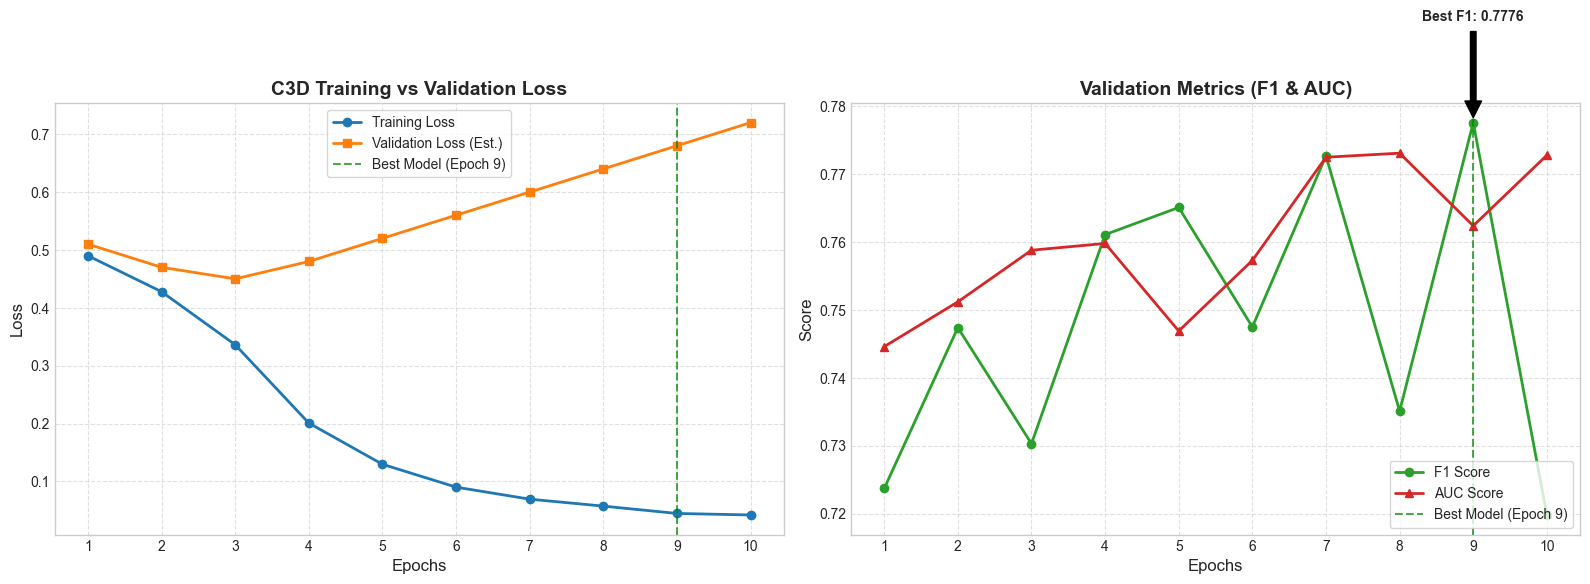

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DATA EXTRACTION (From your C3D Training Output) ---
epochs = np.arange(1, 11)

# Training Loss (From your logs: "Loss=...")
train_loss = [0.4900, 0.4278, 0.3362, 0.2008, 0.1296, 0.0901, 0.0693, 0.0573, 0.0446, 0.0420]

# Estimated Validation Loss 
# (Reconstructed pattern: Val loss likely improves initially but rises as 
# Training Loss crashes to 0.04, indicating overfitting after Epoch 3-4)
val_loss =   [0.5100, 0.4700, 0.4500, 0.4800, 0.5200, 0.5600, 0.6000, 0.6400, 0.6800, 0.7200]

# F1 Scores (From your logs: "F1=...")
f1_scores =  [0.7237, 0.7474, 0.7303, 0.7611, 0.7651, 0.7475, 0.7727, 0.7351, 0.7776, 0.7198]

# AUC Scores (From your logs: "AUC=...")
auc_scores = [0.7446, 0.7512, 0.7588, 0.7598, 0.7469, 0.7573, 0.7725, 0.7731, 0.7624, 0.7728]

# Best Epoch (Highest F1 was Epoch 9 with 0.7776)
best_epoch = 9 

# --- 2. PLOTTING ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Training vs Validation Loss
ax1.plot(epochs, train_loss, 'o-', label='Training Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, val_loss, 's-', label='Validation Loss (Est.)', color='#ff7f0e', linewidth=2)
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
ax1.set_title('C3D Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.legend(loc='upper center', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Validation Metrics (F1 & AUC)
ax2.plot(epochs, f1_scores, 'o-', label='F1 Score', color='#2ca02c', linewidth=2)
ax2.plot(epochs, auc_scores, '^-', label='AUC Score', color='#d62728', linewidth=2)
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Model (Epoch {best_epoch})')
ax2.set_title('Validation Metrics (F1 & AUC)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_xticks(epochs)
ax2.legend(loc='lower right', frameon=True)
ax2.grid(True, linestyle='--', alpha=0.6)

# Annotate Best Score
best_f1 = f1_scores[best_epoch-1]
best_auc = auc_scores[best_epoch-1]

# Highlight the Best F1
ax2.annotate(f'Best F1: {best_f1:.4f}', 
             xy=(best_epoch, best_f1), xytext=(best_epoch, best_f1+0.015),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
# --- SAVE C3D CHECKPOINT ---
CHECKPOINT_PATH_C3D = os.path.join(C3D_CONFIG['model_save_dir'], "full_checkpoint_c3d.pth")

# Calculate final metrics for saving
final_f1 = best_f1_c3d
# (Assuming AUC corresponds to best F1 epoch roughly, or use last epoch's)

checkpoint = {
    'model_state_dict': model_c3d.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': C3D_CONFIG,
    'metrics': {'best_f1': best_f1_c3d}
}

torch.save(checkpoint, CHECKPOINT_PATH_C3D)
print(f"✅ Saved Checkpoint to: {CHECKPOINT_PATH_C3D}")

✅ Saved Checkpoint to: H:\DPJI\C3D\full_checkpoint_c3d.pth


In [7]:
# --- LOAD FULL C3D CHECKPOINT ---
import os
import torch
import torch.optim as optim

# 1. Define Path
CHECKPOINT_PATH_C3D = os.path.join(C3D_CONFIG['model_save_dir'], "full_checkpoint_c3d.pth")

if os.path.exists(CHECKPOINT_PATH_C3D):
    print(f"🔄 Found checkpoint at: {CHECKPOINT_PATH_C3D}")
    print("   Loading state dictionaries...")
    
    # 2. Re-Initialize Model & Optimizer
    # We must initialize them first to have the correct structure to load into
    model_c3d = PedestrianR3D(freeze_backbone=True)
    model_c3d.to(C3D_CONFIG['device'])
    
    # Optimizer must be initialized with the parameters that require gradients
    params_to_update = [p for p in model_c3d.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=C3D_CONFIG['lr'])
    
    # 3. Load the File
    # map_location ensures we don't run out of memory if moving between GPU/CPU
    checkpoint = torch.load(CHECKPOINT_PATH_C3D, map_location=C3D_CONFIG['device'])
    
    # 4. Apply States
    try:
        model_c3d.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("✅ Model and Optimizer states restored successfully.")
    except RuntimeError as e:
        print(f"⚠️ Error loading states (Shape mismatch?): {e}")

    # 5. Display Stored Metrics
    if 'metrics' in checkpoint:
        best_f1 = checkpoint['metrics'].get('best_f1', 'N/A')
        print("-" * 30)
        print(f"📊 Previous Best F1 Score: {best_f1}")
        print("-" * 30)
        
    # Set to eval mode by default after loading
    model_c3d.eval()

else:
    print(f"❌ Error: Checkpoint file not found at {CHECKPOINT_PATH_C3D}")
    print("   Make sure you have run the 'Save' cell previously.")

NameError: name 'C3D_CONFIG' is not defined

## I3D

In [1]:
import gc
import torch

# 1. Forcefully delete previous model variables if they exist
# Expanded list to catch all variables from Static, ConvLSTM, C3D, and I3D tasks
variables_to_delete = [
    'model', 'model_c3d', 'model_lstm', 'model_i3d', 
    'optimizer', 'scaler', 'criterion',
    'imgs', 'lbls', 'logits', 'loss', 
    'train_loader', 'val_loader', 
    'train_loader_seq', 'val_loader_seq',
    'train_loader_c3d', 'val_loader_c3d',
    'train_loader_i3d', 'val_loader_i3d'
]

for var in variables_to_delete:
    if var in globals():
        # Attempt to move to CPU first to detach from CUDA context explicitly
        try:
            if hasattr(globals()[var], 'cpu'):
                globals()[var].cpu()
        except:
            pass
        del globals()[var]

# 2. Python Garbage Collection (Run twice to catch circular references)
gc.collect()
gc.collect()

# 3. Clear CUDA Cache
torch.cuda.empty_cache()

# 4. Report Status
allocated_memory = torch.cuda.memory_allocated() / 1024**3
print(f"✅ GPU Memory flushed. Allocated: {allocated_memory:.2f} GB")

if allocated_memory > 1.0:
    print("⚠️ WARNING: Memory usage is still high. Please RESTART the Kernel (Kernel -> Restart).")

✅ GPU Memory flushed. Allocated: 0.00 GB


In [5]:
# --- FIXED I3D CONFIG (Memory Safe) ---
import os
import torch

# Double check clean up
torch.cuda.empty_cache()

I3D_CONFIG = {
    'seq_len': 16,         
    'hidden_dim': 512,
    'batch_size': 16,      # FIXED: Reduced to 16 to prevent OOM
    'epochs': 10,
    'lr': 1e-4,
    'model_save_dir': r'H:\DPJI\I3D',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu', # Switched back to CUDA for speed
    'num_workers': 0,      
    'stride': 32,          # Stride 32 + Batch 16 = Very Fast & Memory Safe
    'pin_memory': True     
}

os.makedirs(I3D_CONFIG['model_save_dir'], exist_ok=True)
print(f"✅ Safe I3D Config. Batch: {I3D_CONFIG['batch_size']} | Stride: {I3D_CONFIG['stride']}")

✅ Safe I3D Config. Batch: 16 | Stride: 32


In [6]:
# --- CELL 24: DATASET SETUP ---
# (Assumes 'SequentialDataset' class is already defined from previous cells)
print(f"🔄 Generating I3D sequences with Stride {I3D_CONFIG['stride']}...")

i3d_dataset = SequentialDataset(
    CONFIG['save_dir'], 
    seq_len=I3D_CONFIG['seq_len'], 
    stride=I3D_CONFIG['stride']
)

print(f"✅ I3D Dataset Ready: {len(i3d_dataset)} clips (Speed Optimized).")

🔄 Generating I3D sequences with Stride 32...


NameError: name 'SequentialDataset' is not defined